## Project 1

### Part A

In [1]:
import pandas as pd
# Code part A
# Taking the 10 year averaged datasets for offshore wind, onshore wind and pv

offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)

pv = pv_cf.rename(columns={"cf": "pv_cf"})
onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

work_df = pd.concat([pv, onshore, offshore], axis=1)

# Annualised capital costs
offshore_wind_capital_cost = 101644 # EUR/MW/year PLACEHOLDER
onshore_wind_capital_cost = 101644 # EUR/MW/year PLACEHOLDER
pv_capital_cost = 51346 # EUR/MW/year PLACEHOLDER

# Setting up marginal generation costs
onshore_wind_marginal_cost = 0 # EUR/MWh PLACEHOLDER
offshore_wind_marginal_cost = 0 # EUR/MWh PLACEHOLDER
pv_marginal_cost = 0 # EUR/MWh PLACEHOLDER

# Setting up capacities
onshore_wind_capacity = 0 # MW PLACEHOLDER
offshore_wind_capacity = 0 # MW PLACEHOLDER
pv_capacity = 0 # MW PLACEHOLDER

c:\Users\rasmu\anaconda33\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Plots part A
# Martin
work_df.head()

,pv_cf,onshore_cf,offshore_cf
time,,,
01/01 00:00,0.0,0.419545,0.629273
01/01 01:00,0.0,0.407818,0.643364
01/01 02:00,0.0,0.396909,0.644636
01/01 03:00,0.0,0.395182,0.623364
01/01 04:00,0.0,0.386545,0.602273


### Part B

In [ ]:
import pypsa
import pandas as pd
import numpy as np

# ----------------------------
# Create time snapshots
# ----------------------------
hours = pd.date_range("2025-01-01 00:00", periods=24, freq="h")

# Demand profile
load = pd.Series(100.0, index=hours)

# ----------------------------
# Weather year A
# ----------------------------
wind_cf_A = pd.Series(
[0.45,0.42,0.40,0.38,0.35,0.33,0.30,0.32,0.36,0.40,0.43,0.46,
0.48,0.50,0.47,0.44,0.41,0.39,0.37,0.36,0.38,0.41,0.44,0.46],
index=hours)

solar_cf_A = pd.Series(
[0,0,0,0,0,0.02,0.10,0.25,0.45,0.60,0.70,0.75,
0.72,0.65,0.50,0.30,0.12,0.02,0,0,0,0,0,0],
index=hours)

# ----------------------------
# Weather year B
# ----------------------------
wind_cf_B = pd.Series(
[0.22,0.20,0.18,0.17,0.16,0.15,0.14,0.16,0.18,0.20,0.22,0.24,
0.26,0.28,0.27,0.25,0.23,0.22,0.21,0.20,0.21,0.22,0.23,0.24],
index=hours)

solar_cf_B = pd.Series(
[0,0,0,0,0,0.05,0.18,0.35,0.55,0.72,0.82,0.88,
0.84,0.76,0.60,0.40,0.20,0.06,0,0,0,0,0,0],
index=hours)

# ----------------------------
# Model function
# ----------------------------
def run_model(wind_cf, solar_cf, label):

    n = pypsa.Network()
    n.set_snapshots(hours)

    n.add("Bus", "electricity", carrier="electricity")

    n.add("Load",
          "demand",
          bus="electricity",
          p_set=load)

    n.add("Generator",
          "wind",
          bus="electricity",
          p_max_pu=wind_cf,
          capital_cost=600,
          marginal_cost=0,
          p_nom_extendable=True)

    n.add("Generator",
          "solar",
          bus="electricity",
          p_max_pu=solar_cf,
          capital_cost=400,
          marginal_cost=0,
          p_nom_extendable=True)

    n.add("Generator",
          "gas",
          bus="electricity",
          p_max_pu=1,
          capital_cost=800,
          marginal_cost=70,
          p_nom_extendable=True)

    n.optimize()

    result = {
        "year": label,
        "avg_wind_cf": wind_cf.mean(),
        "avg_solar_cf": solar_cf.mean(),
        "wind_capacity": n.generators.at["wind","p_nom_opt"],
        "solar_capacity": n.generators.at["solar","p_nom_opt"],
        "gas_capacity": n.generators.at["gas","p_nom_opt"]
    }

    return n, result


# ----------------------------
# Run both weather years
# ----------------------------
nA, resA = run_model(wind_cf_A, solar_cf_A, "Year A")
nB, resB = run_model(wind_cf_B, solar_cf_B, "Year B")

results = pd.DataFrame([resA,resB])

print(results)

Working directory: c:\Users\rasmu\OneDrive\Documents\Integrated energy grids 46770\Project1\ieg-spring-2026\src

OFFSHORE columns: ['utc_time', 'BEL', 'DEU', 'DNK', 'GBR', 'NLD', 'SWE', 'FIN', 'FRA', 'IRL', 'NOR']
               utc_time    BEL    DEU    DNK    GBR    NLD    SWE    FIN  \
0  1979-01-01T00:00:00Z  0.513  0.875  0.986  0.522  0.484  0.712  0.470   
1  1979-01-01T01:00:00Z  0.367  0.861  0.985  0.549  0.322  0.713  0.384   
2  1979-01-01T02:00:00Z  0.372  0.845  0.978  0.551  0.267  0.711  0.321   
3  1979-01-01T03:00:00Z  0.351  0.819  0.968  0.498  0.274  0.709  0.271   
4  1979-01-01T04:00:00Z  0.338  0.787  0.957  0.457  0.274  0.708  0.224   

     FRA    IRL    NOR  
0  0.296  0.676  0.232  
1  0.331  0.584  0.180  
2  0.343  0.466  0.161  
3  0.223  0.389  0.163  
4  0.189  0.270  0.168  

ONSHORE columns: ['utc_time', 'AUT', 'BEL', 'BGR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'NLD', '

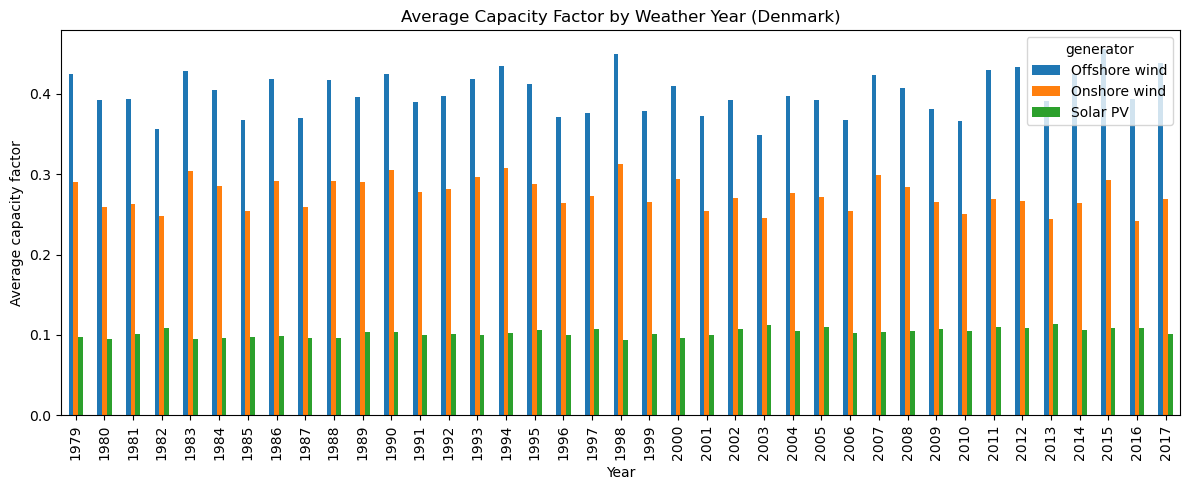

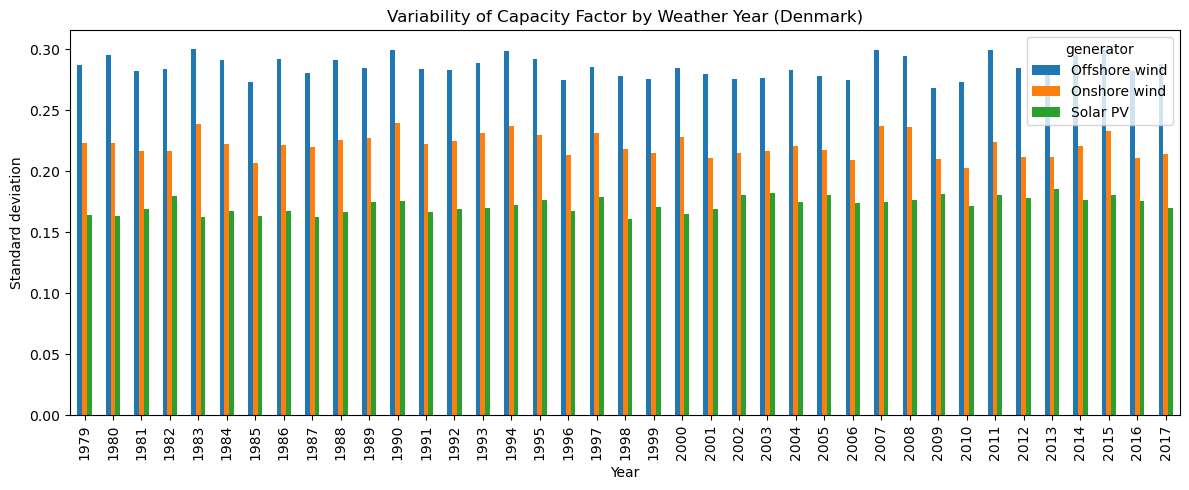

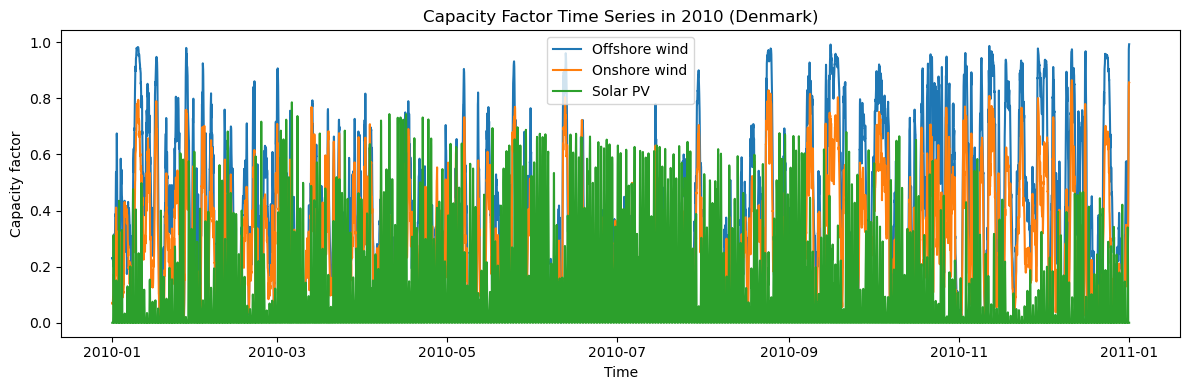

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Working directory:", os.getcwd())

# --------------------------------------------------
# 1. Load raw capacity factor files for Denmark (DNK)
# --------------------------------------------------
offshore = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv", sep=";")
onshore = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", sep=";")
solar = pd.read_csv("../data/pv_capacity_factor_raw.csv", sep=";")

print("\nOFFSHORE columns:", offshore.columns.tolist())
print(offshore.head())

print("\nONSHORE columns:", onshore.columns.tolist())
print(onshore.head())

print("\nSOLAR columns:", solar.columns.tolist())
print(solar.head())

# --------------------------------------------------
# 2. Keep only time + Denmark
# --------------------------------------------------
offshore = offshore[["utc_time", "DNK"]].copy()
onshore = onshore[["utc_time", "DNK"]].copy()
solar = solar[["utc_time", "DNK"]].copy()

# Convert time column to datetime
offshore["utc_time"] = pd.to_datetime(offshore["utc_time"], utc=True, errors="coerce")
onshore["utc_time"] = pd.to_datetime(onshore["utc_time"], utc=True, errors="coerce")
solar["utc_time"] = pd.to_datetime(solar["utc_time"], utc=True, errors="coerce")

# Drop bad rows
offshore = offshore.dropna(subset=["utc_time", "DNK"])
onshore = onshore.dropna(subset=["utc_time", "DNK"])
solar = solar.dropna(subset=["utc_time", "DNK"])

# Rename DNK column to something clearer
offshore = offshore.rename(columns={"DNK": "cf"})
onshore = onshore.rename(columns={"DNK": "cf"})
solar = solar.rename(columns={"DNK": "cf"})

# Add year column
offshore["year"] = offshore["utc_time"].dt.year
onshore["year"] = onshore["utc_time"].dt.year
solar["year"] = solar["utc_time"].dt.year

print("\nYears in offshore:", offshore["year"].min(), "to", offshore["year"].max())
print("Years in onshore:", onshore["year"].min(), "to", onshore["year"].max())
print("Years in solar:", solar["year"].min(), "to", solar["year"].max())

# --------------------------------------------------
# 3. Compute yearly statistics
#    average capacity factor = mean
#    variability = standard deviation
# --------------------------------------------------
offshore_stats = offshore.groupby("year")["cf"].agg(["mean", "std"]).reset_index()
onshore_stats = onshore.groupby("year")["cf"].agg(["mean", "std"]).reset_index()
solar_stats = solar.groupby("year")["cf"].agg(["mean", "std"]).reset_index()

offshore_stats["generator"] = "Offshore wind"
onshore_stats["generator"] = "Onshore wind"
solar_stats["generator"] = "Solar PV"

stats = pd.concat([offshore_stats, onshore_stats, solar_stats], ignore_index=True)
stats = stats.rename(columns={"mean": "average_capacity_factor", "std": "variability"})

print("\n=== YEARLY STATISTICS ===")
print(stats.head(15))

# --------------------------------------------------
# 4. Create tables for plotting
# --------------------------------------------------
avg_table = stats.pivot(index="year", columns="generator", values="average_capacity_factor")
var_table = stats.pivot(index="year", columns="generator", values="variability")

print("\n=== AVERAGE CAPACITY FACTOR TABLE ===")
print(avg_table)

print("\n=== VARIABILITY TABLE ===")
print(var_table)

# --------------------------------------------------
# 5. Plot average capacity factor by year
# --------------------------------------------------
avg_table.plot(kind="bar", figsize=(12, 5))
plt.title("Average Capacity Factor by Weather Year (Denmark)")
plt.ylabel("Average capacity factor")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Plot variability by year
# --------------------------------------------------
var_table.plot(kind="bar", figsize=(12, 5))
plt.title("Variability of Capacity Factor by Weather Year (Denmark)")
plt.ylabel("Standard deviation")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Optional: plot one example year time series
# --------------------------------------------------
example_year = 2010

offshore_example = offshore[offshore["year"] == example_year]
onshore_example = onshore[onshore["year"] == example_year]
solar_example = solar[solar["year"] == example_year]

plt.figure(figsize=(12, 4))
plt.plot(offshore_example["utc_time"], offshore_example["cf"], label="Offshore wind")
plt.plot(onshore_example["utc_time"], onshore_example["cf"], label="Onshore wind")
plt.plot(solar_example["utc_time"], solar_example["cf"], label="Solar PV")
plt.title(f"Capacity Factor Time Series in {example_year} (Denmark)")
plt.ylabel("Capacity factor")
plt.xlabel("Time")
plt.legend()
plt.tight_layout()
plt.show()

### Part C

In [ ]:
# Code part C

In [ ]:
# Plots part C

### Part D

In [ ]:
# Code part D

In [ ]:
# Plots part D

### Part E